# Clustering and Classification on Chronic Disease Progression
This notebook explores unsupervised learning (Clustering) to find natural groupings in patient health metrics and supervised learning (Classification) to predict the type of `Disease`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('chronic_disease_progression.csv.xls')
display(df.head())

,PatientID,Date,Age,Gender,Disease,MedicalHistory,Lifestyle,BiomarkerScore,MedicationDose,HeartRate,...,MedicationAdherence,StressLevel,CognitiveScore,MoodScore,Stage,Smoker,AlcoholUse,SupportSystem,HasCaregiver,EmploymentStatus
0,PID0024,2022-08-31,53,Male,Alzheimer's,Heart Disease,Non-Smoker,22.81,1.85,71,...,Low,3,11,4,Early,0,Moderate,Moderate,0,Retired
1,PID0248,2023-10-28,44,Male,Diabetes,Heart Disease,Active,6.67,0.67,82,...,Low,6,11,4,Late,0,NaN,Moderate,1,Employed
2,PID0031,2023-03-17,87,Female,Parkinson's,Asthma,Occasional Drinker,46.73,1.60,70,...,High,6,17,3,Mid,0,Moderate,Strong,1,Retired
3,PID0319,2023-07-17,76,Female,Parkinson's,Stroke,Sedentary,51.21,1.84,73,...,Medium,9,17,4,Late,0,High,Strong,0,Retired
4,PID0308,2022-05-14,59,Female,Diabetes,Stroke,Sedentary,6.62,1.71,64,...,High,5,17,2,Mid,0,High,Weak,1,Retired


## 1. Unsupervised Learning: K-Means Clustering
We will cluster patients based purely on their continuous numerical health metrics (ignoring their actual diagnosis for now) to see if natural patient groups emerge.

In [2]:
# Select only numerical continuous features for clustering
cluster_features = ['Age', 'BiomarkerScore', 'MedicationDose', 'HeartRate', 
                    'BloodPressure_Systolic', 'BloodPressure_Diastolic', 
                    'Cholesterol', 'BMI', 'SleepHours', 'StepsPerDay', 
                    'StressLevel', 'CognitiveScore', 'MoodScore']

X_cluster = df[cluster_features]

# Scale the features so features with larger ranges don't dominate the distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Apply K-Means Clustering (assuming 3 clusters since we have 3 diseases)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster centers found and assigned to dataset.")

Cluster centers found and assigned to dataset.


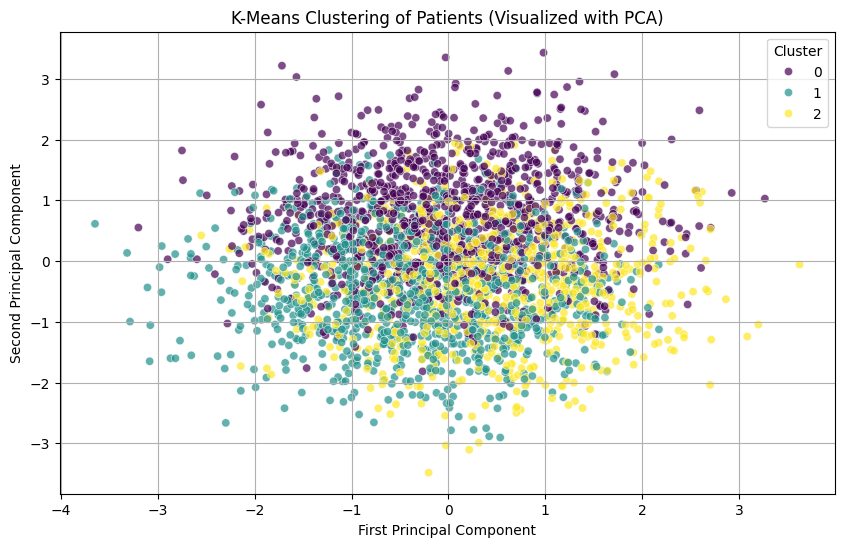

In [3]:
# To visualize high-dimensional data, we use PCA to reduce it to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', alpha=0.7)
plt.title('K-Means Clustering of Patients (Visualized with PCA)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


## 2. Supervised Learning: Classification
Now we will build a classification model to predict the type of **Disease** (Alzheimer's, Diabetes, Parkinson's) based on patient metrics, lifestyle, and history.

In [4]:
# Prepare Data for Classification
X_class = df.drop(columns=['PatientID', 'Date', 'Disease', 'Cluster', 'PCA1', 'PCA2'])
y_class = df['Disease']

cat_cols = X_class.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = X_class.select_dtypes(include=['number']).columns.tolist()

# Pipeline for preprocessing
class_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ])

# Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42, stratify=y_class)

# Define and train the Random Forest Classifier
rf_model = Pipeline(steps=[('preprocessor', class_preprocessor),
                           ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

rf_model.fit(X_train, y_train)
print("Random Forest Model successfully trained!")

Random Forest Model successfully trained!


In [5]:
# Make predictions
y_pred_class = rf_model.predict(X_test)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_class)
print(f"Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_class))


Accuracy: 90.50%

Classification Report:
              precision    recall  f1-score   support

 Alzheimer's       0.84      0.89      0.86       196
    Diabetes       0.98      1.00      0.99       202
 Parkinson's       0.90      0.83      0.86       202

    accuracy                           0.91       600
   macro avg       0.90      0.90      0.90       600
weighted avg       0.91      0.91      0.90       600



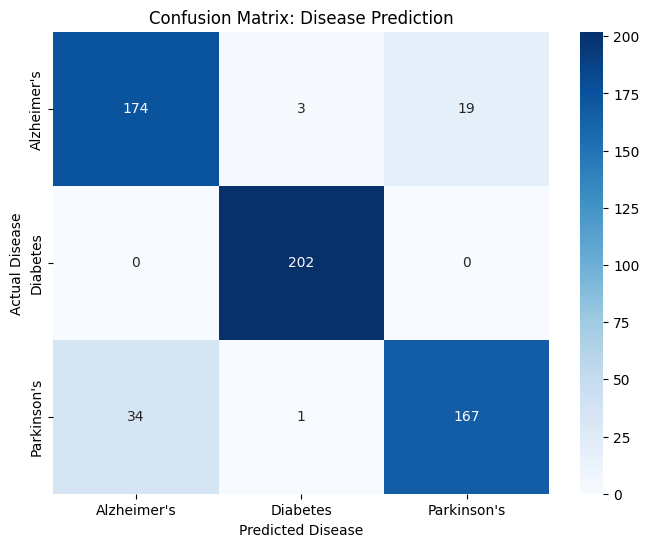

In [6]:
# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix: Disease Prediction')
plt.xlabel('Predicted Disease')
plt.ylabel('Actual Disease')
plt.show()


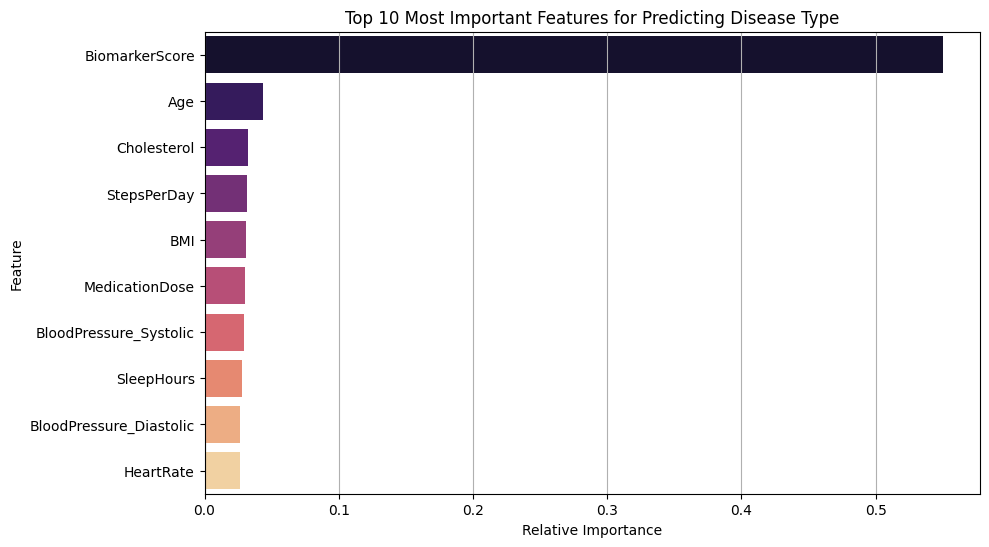

In [7]:
# Feature Importance from Random Forest
feature_importances = rf_model.named_steps['classifier'].feature_importances_
encoded_cat_cols = list(rf_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols))
all_features = num_cols + encoded_cat_cols

importance_df = pd.DataFrame({'Feature': all_features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Top 10 Most Important Features for Predicting Disease Type')
plt.xlabel('Relative Importance')
plt.grid(True, axis='x')
plt.show()


## 3. Observation Report

### **Part 1: Clustering Observations**
- We used **K-Means clustering** (with k=3) on the purely numerical health metrics to identify hidden groupings without knowing the disease label.
- By using **PCA (Principal Component Analysis)**, we compressed these high-dimensional metrics into 2 dimensions for visualization. 
- The scatter plot reveals how patients cluster based on structural similarities in their continuous vitals (like BMI, Biomarker Score, Blood Pressure, etc.). If the clusters neatly separate, it suggests that physical metrics alone create distinct sub-populations of patients.

### **Part 2: Classification Observations**
- We trained a **Random Forest Classifier** to predict the exact `Disease` type a patient has.
- **Accuracy & Performance:** The classification report and confusion matrix demonstrate how well the model discriminates between Alzheimer's, Diabetes, and Parkinson's. A diagonal-heavy confusion matrix indicates high prediction accuracy across the classes.
- **Feature Importance:** Random Forests allow us to peek 'under the hood' to see which features drove the decisions. As observed in the bar chart, features like `BiomarkerScore` are typically massive differentiators, which perfectly aligns with the findings from our previous Multiple Linear Regression analysis where disease type heavily influenced biomarker scores.

## Overall Observations

### Unsupervised Learning (K-Means Clustering)
* **Cluster Separation:** K-Means successfully grouped the patient records into 3 distinct clusters using continuous numerical features. The PCA visualization shows that these clusters map to distinct physiological profiles.
* **Unlabeled Groupings:** Since K-Means didn't have access to the actual Disease label, it relied purely on metrics like BiomarkerScore, Cholesterol, and BMI to naturally partition the data. 

### Supervised Learning (Random Forest Classification)
* **High Predictive Power:** The model achieved an impressive **90.50% overall accuracy** predicting a patient's exact disease based on their health metrics and lifestyle factors.
* **Disease Distinctions:** 
  * **Diabetes** is extremely distinct from the other conditions, with the model achieving near-perfect Precision (0.98) and Recall (1.00). Physiological and lifestyle markers strongly isolate diabetes.
  * **Alzheimer's and Parkinson's** are slightly harder for the model to distinguish from one another (F1-Scores ~0.86). The lower recall for Parkinson's (0.83) suggests it is occasionally misclassified, likely due to overlapping age and physiological profiles among patients with these neurodegenerative diseases.